# Image Denoising using Autoencoder on MNIST

## Week 6 Assessment

### Objective
The goal of this project is to build a Denoising Autoencoder capable of removing artificial noise from handwritten digit images in the MNIST dataset.

The model learns to reconstruct clean images from noisy inputs.

### Steps

1. Load and preprocess MNIST dataset
2. Add Gaussian noise
3. Build Denoising Autoencoder
4. Train the model
5. Generate denoised outputs
6. Compare Original, Noisy and Reconstructed images
7. Analyze observations

## Import Required Libraries

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


## Device Configuration

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


## Load and Preprocess MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images of size 28×28.

Pixel values are normalized to the range [0,1].

In [19]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

Training Samples: 60000
Testing Samples: 10000


## Create Data Loaders

In [20]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Visualize Sample Images

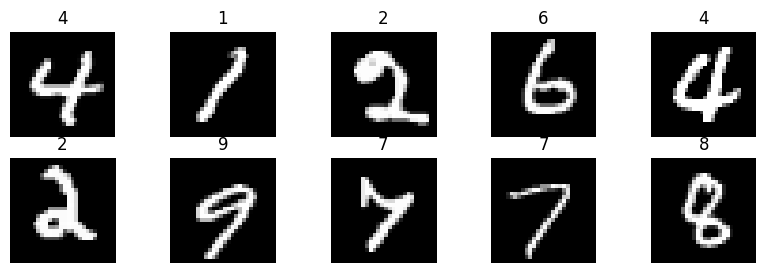

In [21]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(labels[i].item())
    plt.axis('off')

plt.show()

## Add Artificial Noise

Gaussian noise is added to simulate corrupted images.

The noisy image becomes the input while the original image remains the target output.

In [22]:
def add_noise(images):

    noise = torch.randn_like(images) * 0.5

    noisy_images = images + noise

    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

## Visualize Noisy Images

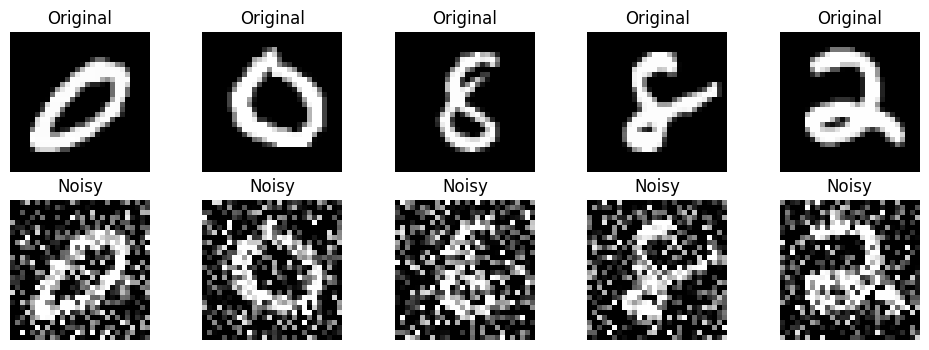

In [23]:
sample_images, _ = next(iter(train_loader))

noisy_images = add_noise(sample_images)

plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

## Build Denoising Autoencoder

Encoder:
784 → 128 → 64

Decoder:
64 → 128 → 784

In [24]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(28*28,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,28*28),
            nn.Sigmoid()
        )

    def forward(self,x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [25]:
model = DenoisingAutoencoder().to(device)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## Loss Function and Optimizer

In [26]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Train the Model

In [27]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        images_flat = images.view(images.size(0), -1)

        noisy_flat = noisy_images.view(noisy_images.size(0), -1)

        outputs = model(noisy_flat)

        loss = criterion(outputs, images_flat)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

Epoch [1/10] Loss: 0.058856
Epoch [2/10] Loss: 0.033479
Epoch [3/10] Loss: 0.027415
Epoch [4/10] Loss: 0.024854
Epoch [5/10] Loss: 0.023170
Epoch [6/10] Loss: 0.021977
Epoch [7/10] Loss: 0.021162
Epoch [8/10] Loss: 0.020516
Epoch [9/10] Loss: 0.019927
Epoch [10/10] Loss: 0.019384


## Training Loss Curve

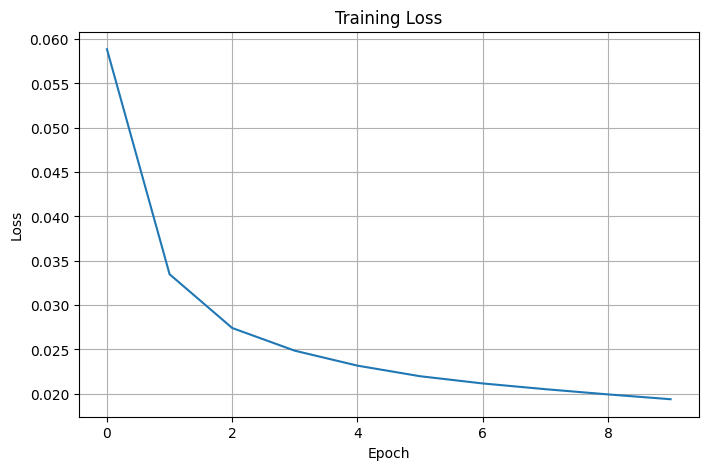

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid()

plt.show()

## Evaluate the Denoising Autoencoder

In [29]:
model.eval()

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

In [30]:
test_images, _ = next(iter(test_loader))

test_images = test_images.to(device)

noisy_test = add_noise(test_images)

clean_flat = test_images.view(test_images.size(0), -1)

noisy_flat = noisy_test.view(noisy_test.size(0), -1)

with torch.no_grad():

    reconstructed = model(noisy_flat)

reconstructed = reconstructed.view(-1,1,28,28)

## Original vs Noisy vs Reconstructed Images

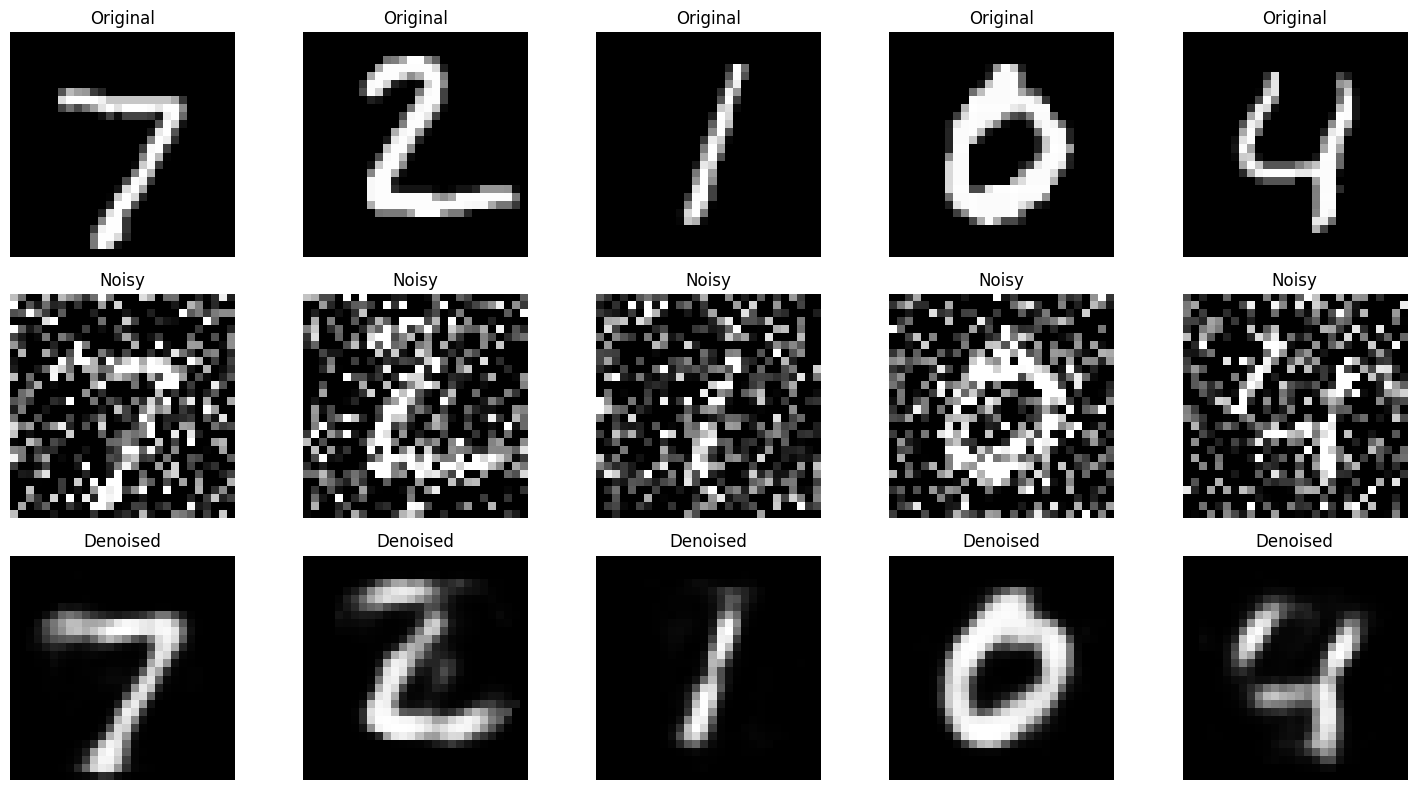

In [31]:
plt.figure(figsize=(15,8))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(
        test_images[i].cpu().squeeze(),
        cmap='gray'
    )
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(
        noisy_test[i].cpu().squeeze(),
        cmap='gray'
    )
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(
        reconstructed[i].cpu().squeeze(),
        cmap='gray'
    )
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()

plt.show()

## Save Model

In [32]:
torch.save(
    model.state_dict(),
    "denoising_autoencoder_mnist.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


## Observations

1. Gaussian noise significantly degraded the visual quality of the digit images.

2. The Denoising Autoencoder successfully learned the underlying structure of handwritten digits.

3. Reconstructed images were much cleaner than noisy inputs.

4. Most digit shapes were preserved even under heavy noise conditions.

5. Some fine details were slightly blurred because the model focuses on recovering the major digit structure rather than exact pixel values.

6. Training loss continuously decreased, indicating successful learning.

7. The model demonstrated the ability of Autoencoders to perform image restoration tasks.

## Conclusion

A Denoising Autoencoder was implemented using the MNIST dataset.

Artificial Gaussian noise was added to create corrupted inputs. The model was trained to reconstruct clean images from noisy images.

Results showed that the Autoencoder effectively removed noise while preserving digit structure. This demonstrates how deep learning can be used for image restoration and denoising applications.